In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

In [4]:
dataset_path = Path("../data/CHEST X RAY")
train_path = dataset_path / "train"
test_path = dataset_path / "test"

print(train_path)
print(test_path)

..\data\CHEST X RAY\train
..\data\CHEST X RAY\test


In [5]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [6]:
# Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 4246 files belonging to 2 classes.
Using 3397 files for training.


In [7]:
# Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 4246 files belonging to 2 classes.
Using 849 files for validation.


In [8]:
# Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1622 files belonging to 2 classes.


In [57]:
# Class Names
class_names = train_ds.class_names

print(class_names)

['NORMAL', 'PNEUMONIA']


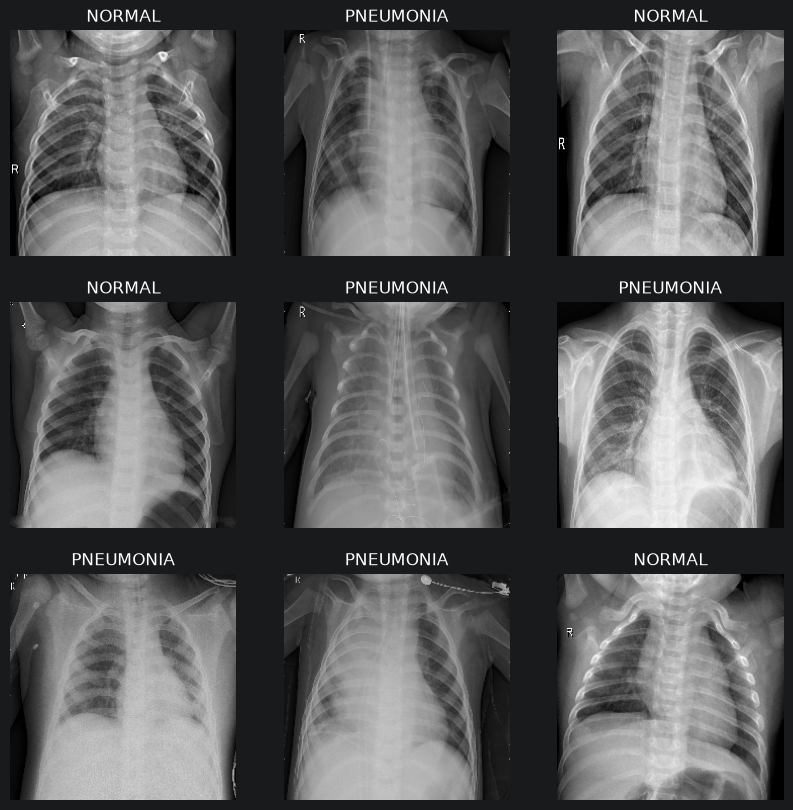

In [58]:
# Visualize Training Images
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

## Performance Optimization

In [59]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

## Data Augmentation

In [60]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## Test Augmentation

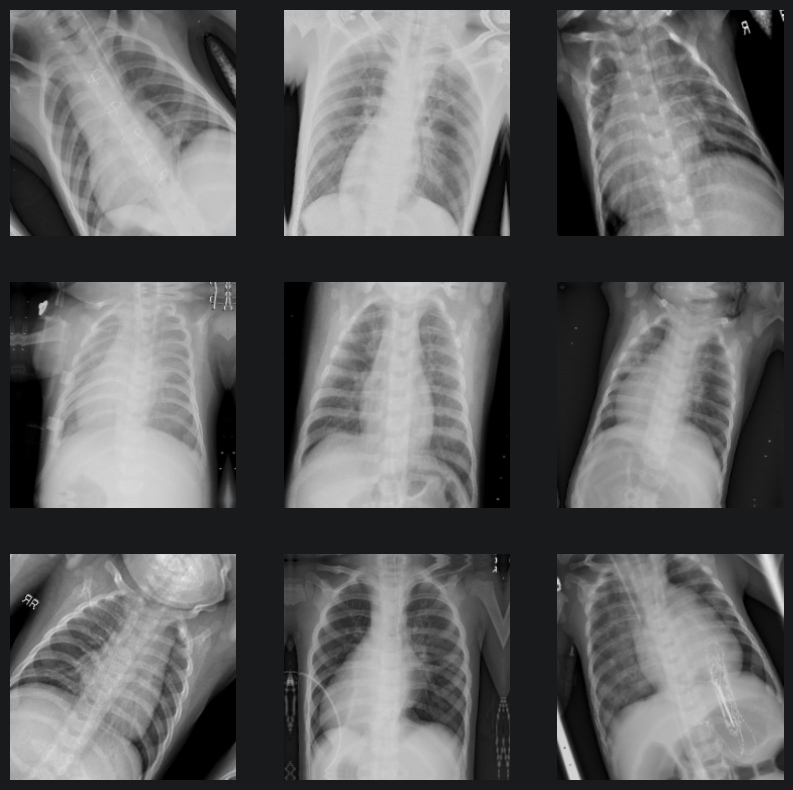

In [61]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.axis("off")

## Check Dataset Shapesm

In [62]:
for images, labels in train_ds.take(1):
    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


## Import Model Resnet50

In [63]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

## Freeze the Base Model

In [64]:
base_model.trainable = False

# Build the Model

In [65]:
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.resnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(2, activation="softmax")(x)

model = keras.Model(inputs, outputs)

## Model Summary

In [66]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ sequential_1[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │        258 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [67]:
## Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Callbacks

In [68]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "../models/resnet50_pneumonia.keras",
        save_best_only=True
    ),

    keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        factor=0.2,
        patience=2
    )
]

In [69]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.7698 - loss: 0.5207 - val_accuracy: 0.9187 - val_loss: 0.2057 - learning_rate: 1.0000e-04
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 99s 927ms/step - accuracy: 0.8820 - loss: 0.2907 - val_accuracy: 0.9258 - val_loss: 0.1728 - learning_rate: 1.0000e-04
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 94s 880ms/step - accuracy: 0.8867 - loss: 0.2677 - val_accuracy: 0.9317 - val_loss: 0.1663 - learning_rate: 1.0000e-04
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 773ms/step - accuracy: 0.9076 - loss: 0.2302 - val_accuracy: 0.9376 - val_loss: 0.1452 - learning_rate: 1.0000e-04
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 85s 796ms/step - accuracy: 0.9143 - loss: 0.2090 - val_accuracy: 0.9435 - val_loss: 0.1466 - learning_rate: 1.0000e-04
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 86s 805ms/step - accuracy: 0.9173 - loss: 0.2056 - val_accuracy: 0.9446 - val_loss: 0.1364 - learning_rate: 1.0000e-04
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 85s 792m

In [70]:
model.save("models/final_resnet50.keras")

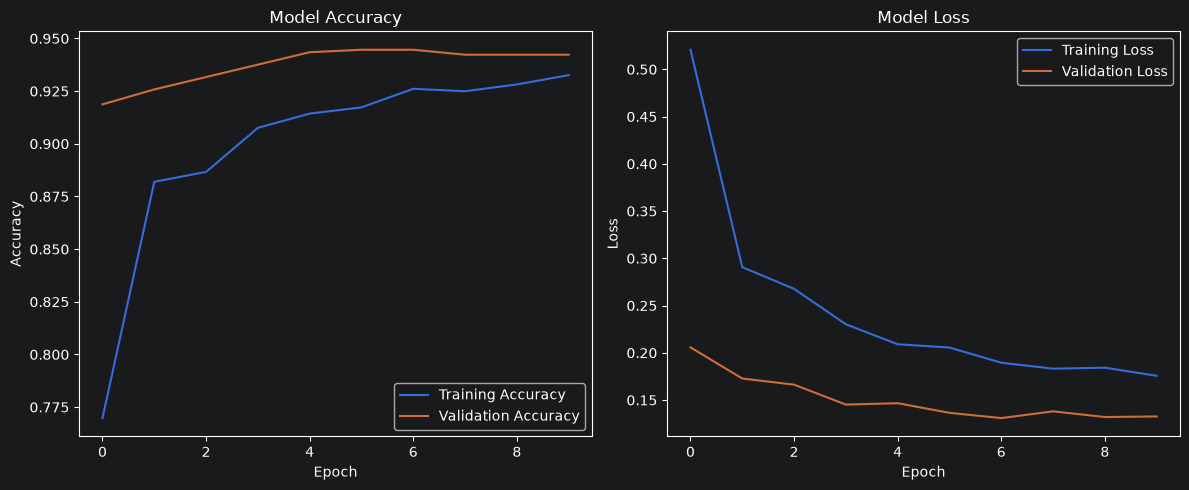

In [71]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate on the Test Set

In [73]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 30s 573ms/step - accuracy: 0.9538 - loss: 0.1298

Test Accuracy: 0.9538
Test Loss: 0.1298


## Predictions

In [74]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

## Classification Report

In [76]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      NORMAL       0.90      0.91      0.91       398
   PNEUMONIA       0.97      0.97      0.97      1224

    accuracy                           0.95      1622
   macro avg       0.94      0.94      0.94      1622
weighted avg       0.95      0.95      0.95      1622



## Confusion Matrix

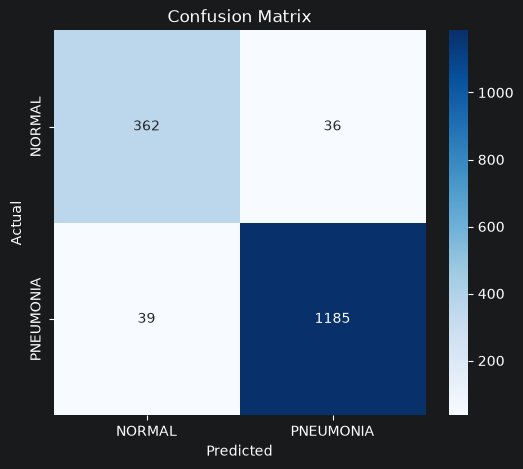

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Comparing Models

In [9]:
from tensorflow import keras

best_model = keras.models.load_model("../models/resnet50_pneumonia.keras")

loss1, acc1 = best_model.evaluate(test_ds)

print("Checkpoint Model")
print("Accuracy:", acc1)
print("Loss:", loss1)

51/51 ━━━━━━━━━━━━━━━━━━━━ 32s 594ms/step - accuracy: 0.9538 - loss: 0.1298
Checkpoint Model
Accuracy: 0.9537608027458191
Loss: 0.12977026402950287


In [11]:
# final model
final_model = keras.models.load_model("../models/final_resnet50.keras")

loss2, acc2 = final_model.evaluate(test_ds)

print("Final Model")
print("Accuracy:", acc2)
print("Loss:", loss2)

51/51 ━━━━━━━━━━━━━━━━━━━━ 29s 532ms/step - accuracy: 0.9538 - loss: 0.1298
Final Model
Accuracy: 0.9537608027458191
Loss: 0.12977026402950287
